# Before Starting

Make sure that we have access to GPU. We can use nvidia-smi command to do that. In case of any problems navigate to Edit -> Notebook settings -> Hardware accelerator, set it to GPU, and then click Save.

In [ ]:
!nvidia-smi

Tue Apr 16 17:55:49 2024       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.104.05             Driver Version: 535.104.05   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  Tesla T4                       Off | 00000000:00:04.0 Off |                    0 |
| N/A   64C    P8              10W /  70W |      0MiB / 15360MiB |      0%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----------------------+--

In [ ]:
import torch

# Check PyTorch GPU availability
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"GPU Is Available: {torch.cuda.is_available()}")
else:
    print("GPU is not available.")

GPU Name: Tesla T4
GPU Is Available: True


HOME Constant for directory

In [ ]:
import os
HOME = os.getcwd()
print(HOME)

/content


# Import Dependencies

YoloV9 is still new, to avoid bugs as recommended we used a fork version,

In [ ]:
!git clone https://github.com/SkalskiP/yolov9.git
%cd yolov9
!pip install -r requirements.txt

Cloning into 'yolov9'...
remote: Enumerating objects: 325, done.
remote: Total 325 (delta 0), reused 0 (delta 0), pack-reused 325
Receiving objects: 100% (325/325), 2.25 MiB | 12.45 MiB/s, done.
Resolving deltas: 100% (164/164), done.
/content/YOLOv9_DeepSORT/yolov9
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.7/62.7 kB 7.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 16.5 MB/s eta 0:00:00


Deep Sort

In [ ]:
%cd /content/

/content


In [ ]:
!pwd

/content


In [ ]:
!git clone https://github.com/sujanshresstha/YOLOv9_DeepSORT.git
%cd YOLOv9_DeepSORT
!pip install -q -r requirements.txt

Cloning into 'YOLOv9_DeepSORT'...
remote: Enumerating objects: 60, done.
remote: Counting objects: 100% (60/60), done.
remote: Compressing objects: 100% (51/51), done.
remote: Total 60 (delta 27), reused 18 (delta 5), pack-reused 0
Receiving objects: 100% (60/60), 16.86 MiB | 10.36 MiB/s, done.
Resolving deltas: 100% (27/27), done.
/content/YOLOv9_DeepSORT
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 22.1 MB/s eta 0:00:00


Roboflow

In [ ]:
%cd {HOME}/yolov9
!pip install -q roboflow

/content/yolov9
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.1/74.1 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 158.3/158.3 kB 7.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.7/178.7 kB 10.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 7.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.1/49.1 MB 13.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 8.1 MB/s eta 0:00:00


# Download Model Weight for YOLOv9

In [ ]:
!wget -P {HOME}/weights -q https://github.com/WongKinYiu/yolov9/releases/download/v0.1/yolov9-e.pt

In [ ]:
!ls -la {HOME}/weights

total 136940
drwxr-xr-x 2 root root      4096 Apr 16 17:57 .
drwxr-xr-x 1 root root      4096 Apr 16 17:57 ..
-rw-r--r-- 1 root root 140217688 Feb 18 12:36 yolov9-e.pt


# Download Dataset from Roboflow (Good Weather)

In [ ]:
%cd yolov9

[Errno 2] No such file or directory: 'yolov9'
/content/yolov9


In [ ]:
from roboflow import Roboflow
rf = Roboflow(api_key="redacted")
project = rf.workspace("dataset-125vd").project("helmet-detection-good-weather")
version = project.version(2)
dataset = version.download("yolov9")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to helmet-detection-good-weather-2 in yolov9:: 100%|██████████| 942/942 [00:00<00:00, 7969.68it/s]


# Train Custom YOLOV9 Object Detection Model on Custom Good Weather Dataset

Make sure to modify the /content/yolov9/models/detect/yolov9-e.yaml and change the parameter of nc: 80 to nc: 3 to indicate the number of classes that will be used to detect the objects

In [ ]:
{dataset.location}

{'/content/yolov9/helmet-detection-good-weather-2'}

# YOLOv9 with Default Hyperparameters lr0=0.01, epochs=50, batch=8 (1)

In [ ]:
%cd {HOME}/yolov9

!python train_dual.py \
--workers 8 --batch 8 --epochs 50 --img 640 --device 0 \
--data {dataset.location}/data.yaml \
--weights {HOME}/weights/yolov9-e.pt \
--cfg models/detect/yolov9-e.yaml \
--hyp hyp.scratch-high.yaml

/content/yolov9
2024-04-16 17:59:08.756878: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-04-16 17:59:08.756933: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-04-16 17:59:08.758405: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-04-16 17:59:10.191168: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
train_dual: weights=/content/weights/yolov9-e.pt, cfg=models/detect/yolov9-e.yaml, data=/content/yolov9/helmet-detection-good-weather-2/data.yaml, hyp=hyp.scratch-high.yaml, epochs=50, batch_size=8, imgsz=640, rect=False, res

## Analyze Training Results

**NOTE:** By default, the results of each subsequent training sessions are saved in `{HOME}/yolov9/runs/train/`, in directories named `exp`, `exp2`, `exp3`, ... You can override this behavior by using the `--name` parameter.

In [ ]:
!ls {HOME}/yolov9/runs/train/exp/

confusion_matrix.png				    PR_curve.png	   val_batch0_pred.jpg
events.out.tfevents.1713290351.539b6e758ae3.1378.0  R_curve.png		   val_batch1_labels.jpg
F1_curve.png					    results.csv		   val_batch1_pred.jpg
hyp.yaml					    results.png		   val_batch2_labels.jpg
labels_correlogram.jpg				    train_batch0.jpg	   val_batch2_pred.jpg
labels.jpg					    train_batch1.jpg	   weights
opt.yaml					    train_batch2.jpg
P_curve.png					    val_batch0_labels.jpg


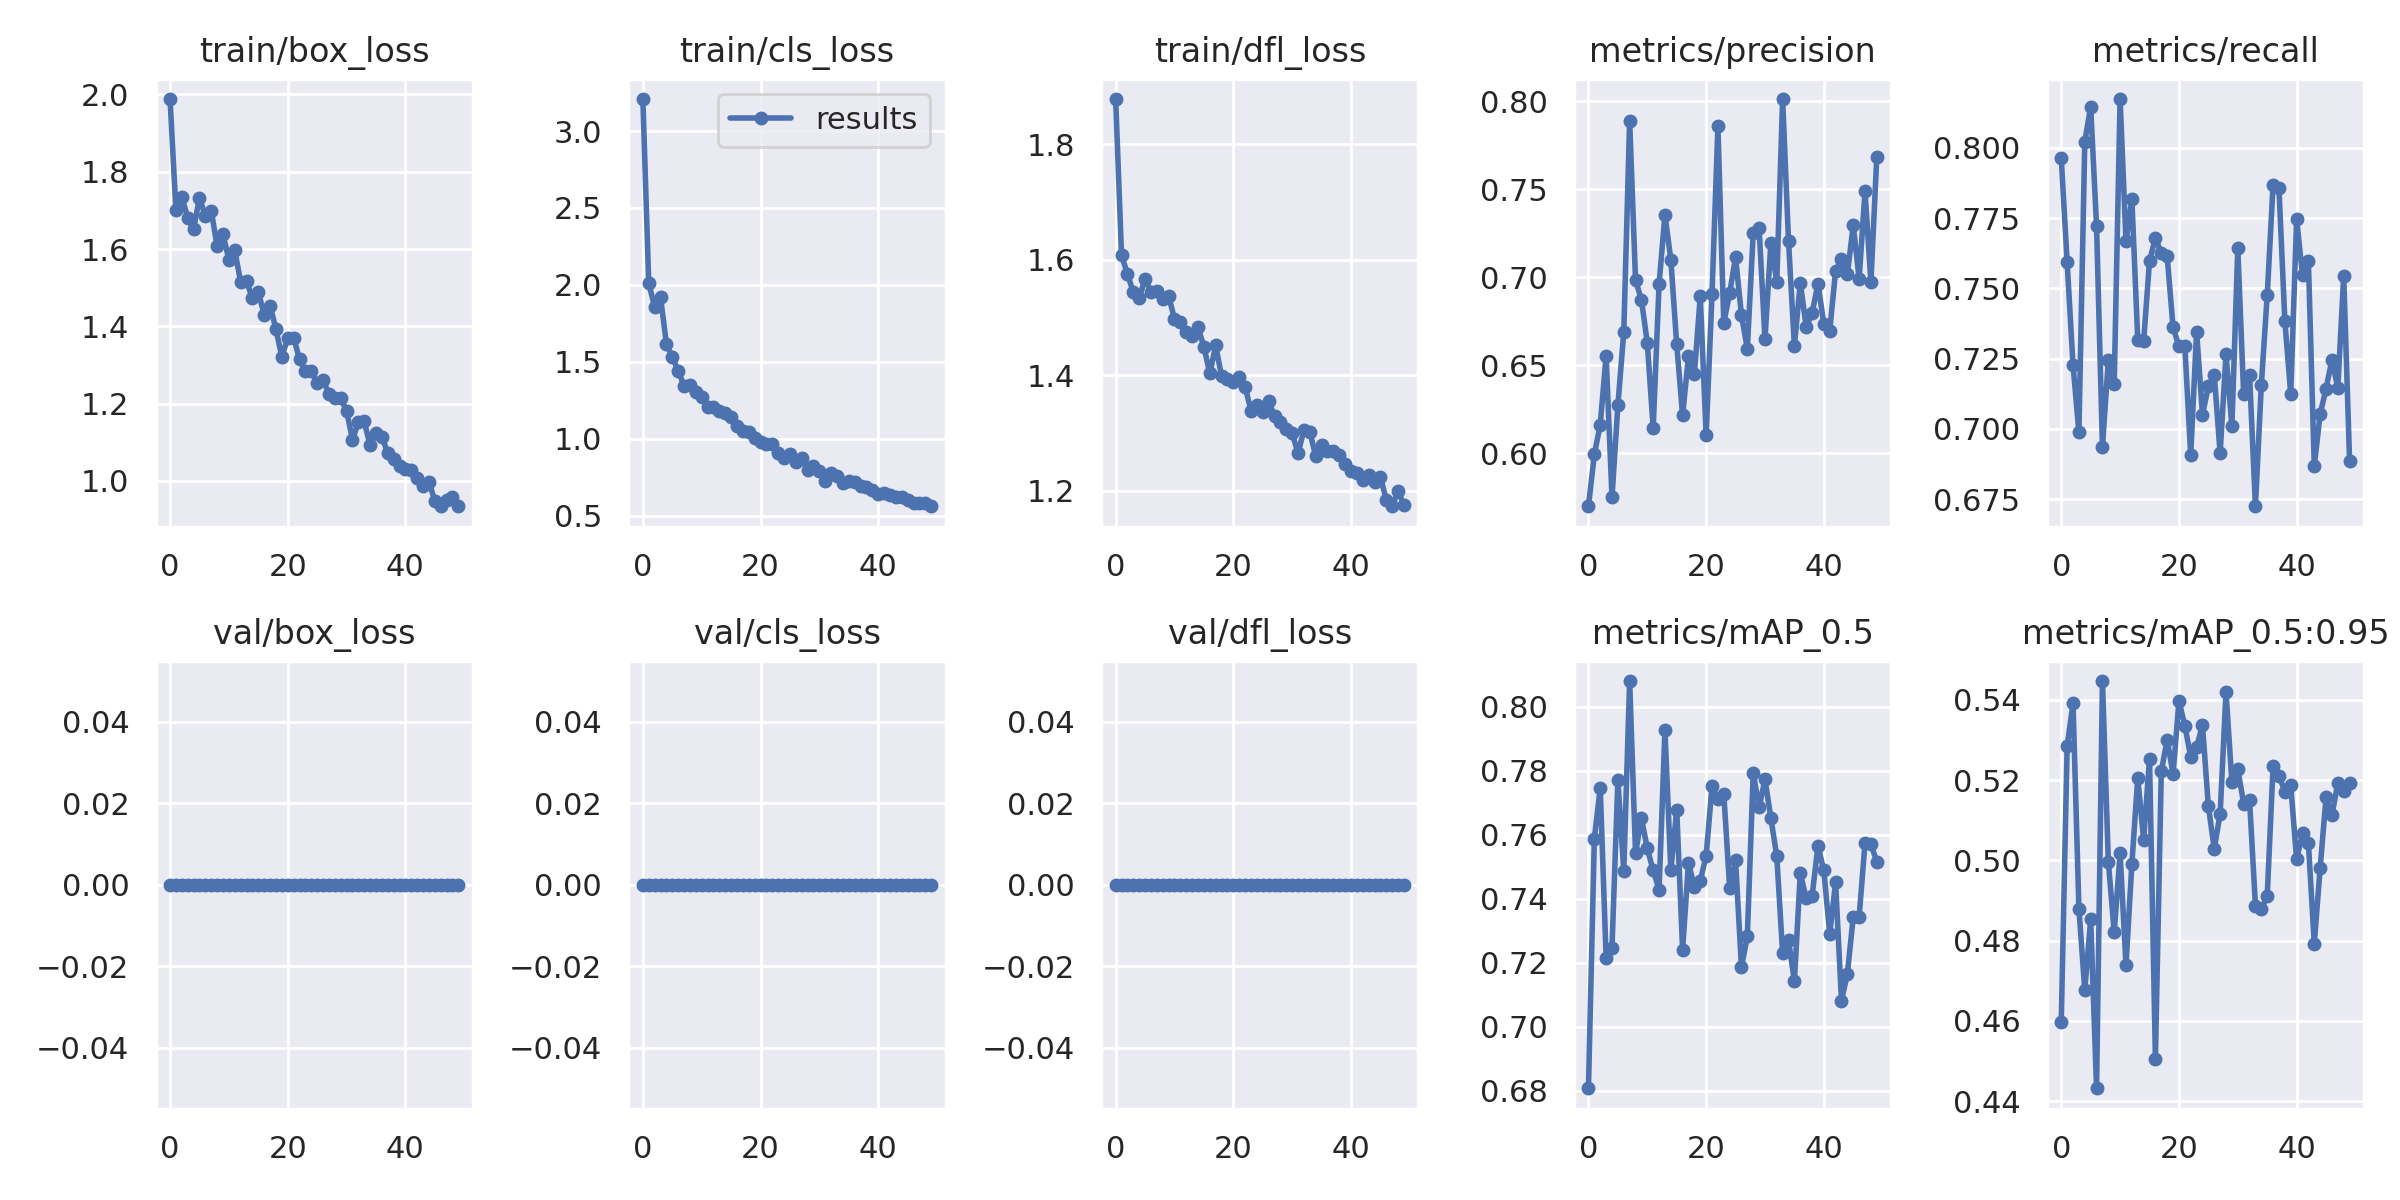

In [ ]:
from IPython.display import Image

Image(filename=f"{HOME}/yolov9/runs/train/exp/results.png", width=1000)

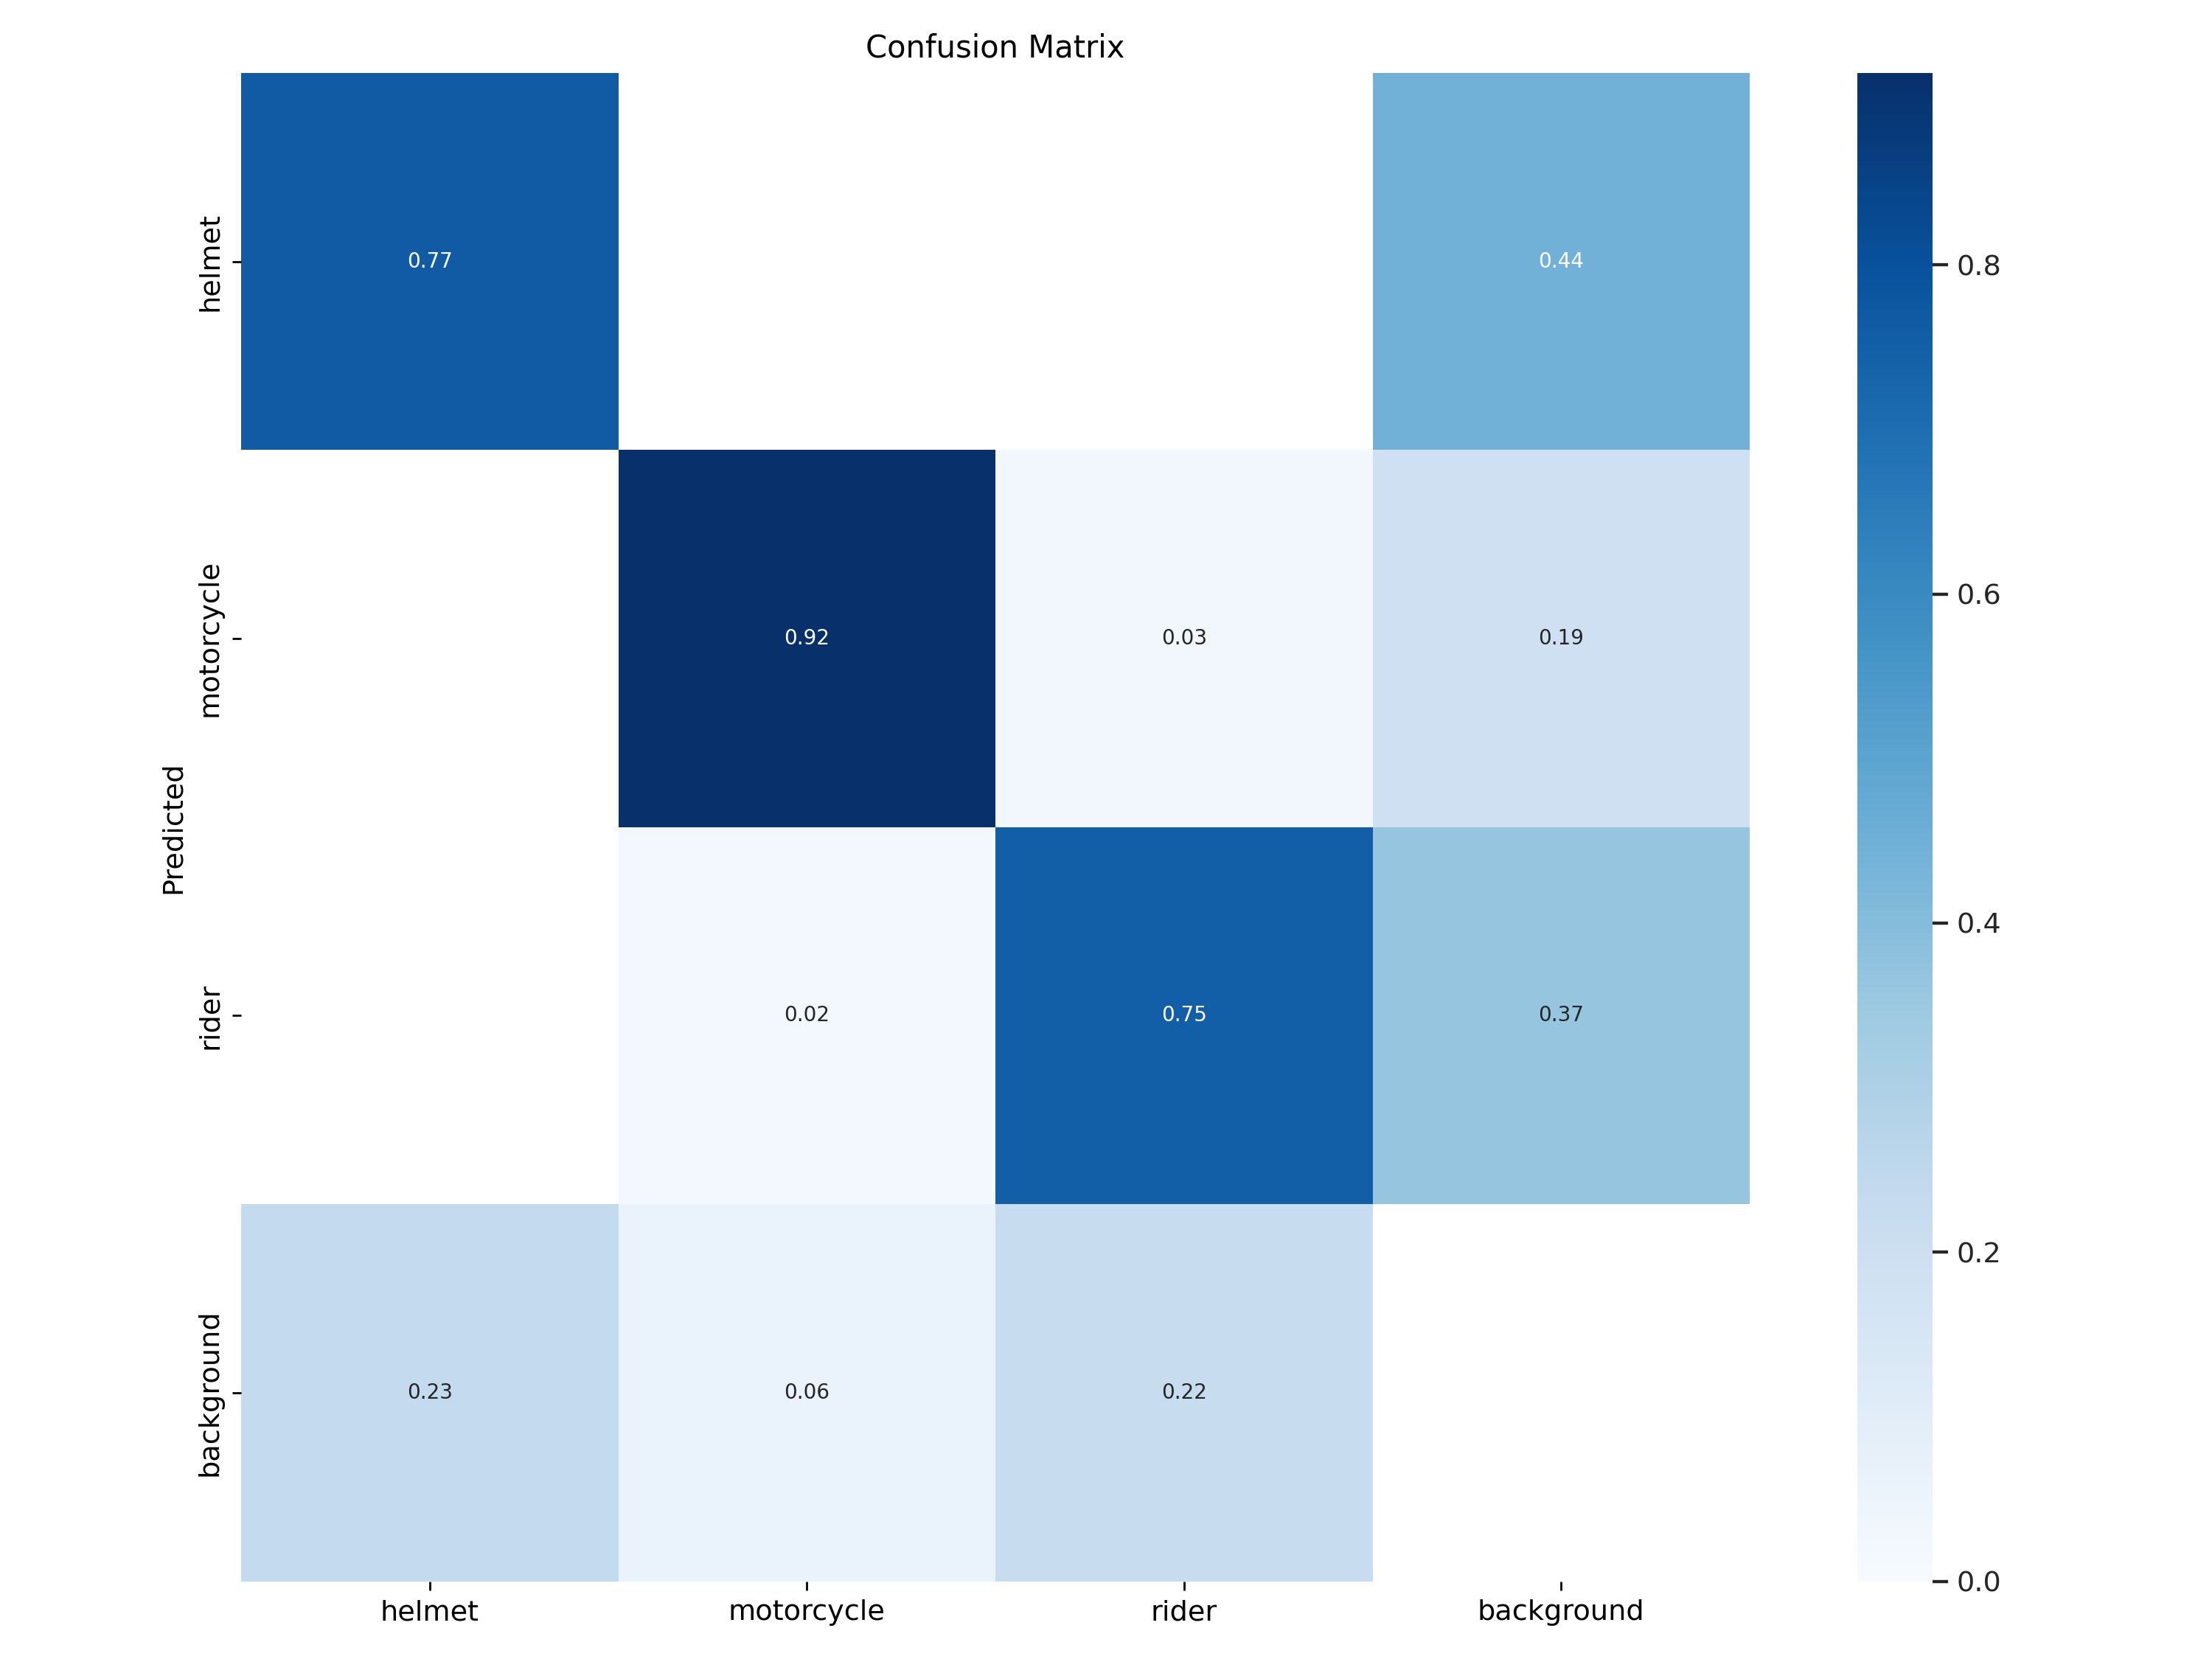

In [ ]:
from IPython.display import Image

Image(filename=f"{HOME}/yolov9/runs/train/exp/confusion_matrix.png", width=1000)

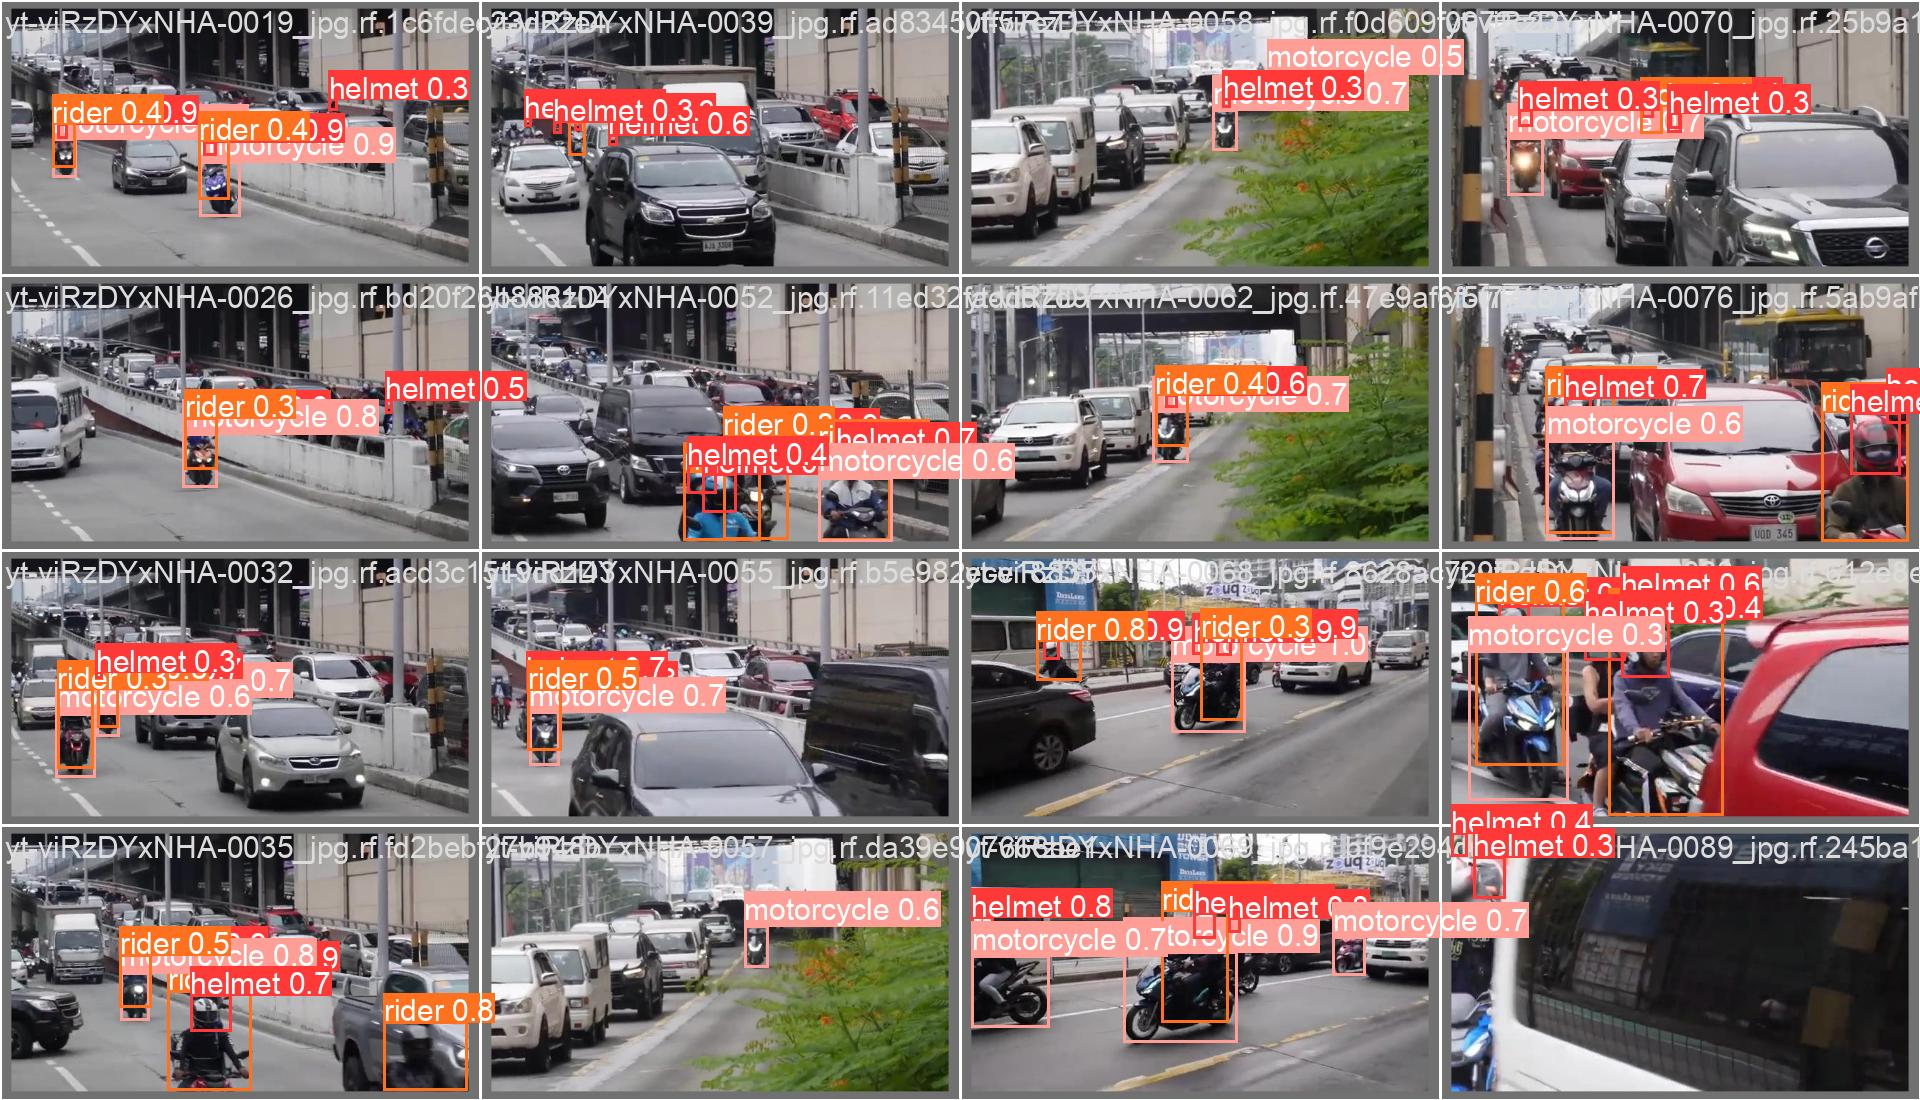

In [ ]:
from IPython.display import Image

Image(filename=f"{HOME}/yolov9/runs/train/exp/val_batch0_pred.jpg", width=1000)

## Validate Custom YOLOv9 Helmet Object Detection Model on Custom Dataset

In [ ]:
%cd {HOME}/yolov9

!python val_dual.py \
--img 640 --batch 16 --conf 0.001 --iou 0.7 --device 0 \
--data {dataset.location}/data.yaml \
--weights {HOME}/yolov9/runs/train/exp/weights/best.pt

/content/yolov9
val_dual: data=/content/yolov9/helmet-detection-good-weather-2/data.yaml, weights=['/content/yolov9/runs/train/exp/weights/best.pt'], batch_size=16, imgsz=640, conf_thres=0.001, iou_thres=0.7, max_det=300, task=val, device=0, workers=8, single_cls=False, augment=False, verbose=False, save_txt=False, save_hybrid=False, save_conf=False, save_json=False, project=runs/val, name=exp, exist_ok=False, half=False, dnn=False, min_items=0
YOLOv5 🚀 1e33dbb Python-3.10.12 torch-2.2.1+cu121 CUDA:0 (Tesla T4, 15102MiB)

Fusing layers... 
yolov9-e summary: 1119 layers, 69351410 parameters, 0 gradients, 243.3 GFLOPs
val: Scanning /content/yolov9/helmet-detection-good-weather-2/valid/labels.cache... 38 images, 3 backgrounds, 0 corrupt: 100% 38/38 [00:00<?, ?it/s]
/usr/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fo

## Inference with Custom Model

In [ ]:
!python detect.py \
--img 640 --conf 0.1 --device 0 \
--weights {HOME}/yolov9/runs/train/exp/weights/best.pt \
--source {dataset.location}/test/images

detect: weights=['/content/yolov9/runs/train/exp/weights/best.pt'], source=/content/yolov9/helmet-detection-good-weather-2/test/images, data=data/coco128.yaml, imgsz=[640, 640], conf_thres=0.1, iou_thres=0.45, max_det=1000, device=0, view_img=False, save_txt=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=exp, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5 🚀 1e33dbb Python-3.10.12 torch-2.2.1+cu121 CUDA:0 (Tesla T4, 15102MiB)

Fusing layers... 
yolov9-e summary: 1119 layers, 69351410 parameters, 0 gradients, 243.3 GFLOPs
image 1/19 /content/yolov9/helmet-detection-good-weather-2/test/images/yt-viRzDYxNHA-0006_jpg.rf.00f64741fbf5e883cc4ebb7138f8e71a.jpg: 384x640 10 helmets, 6 motorcycles, 8 riders, 166.9ms
image 2/19 /content/yolov9/helmet-detection-good-weather-2/test/images/yt-viRzDYxNHA-0009_jpg.rf.dfc8c9934

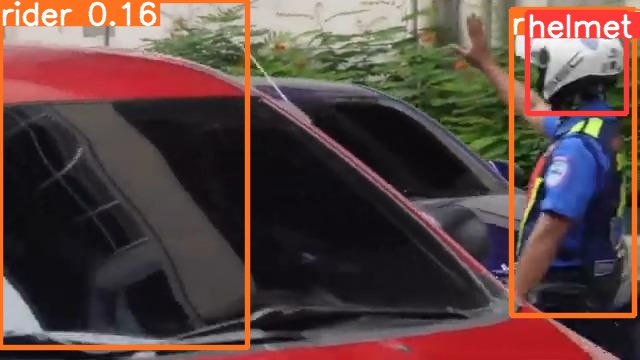

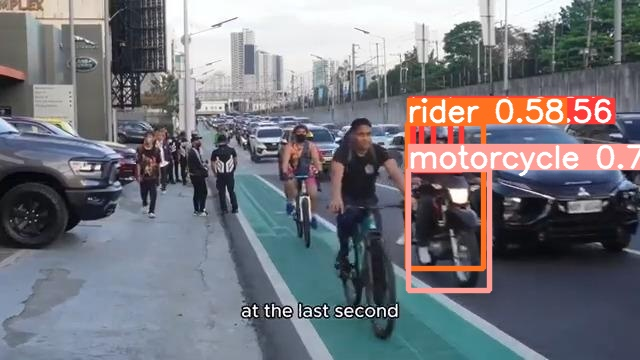

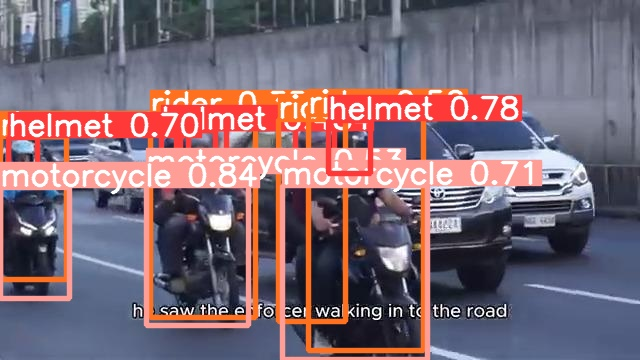

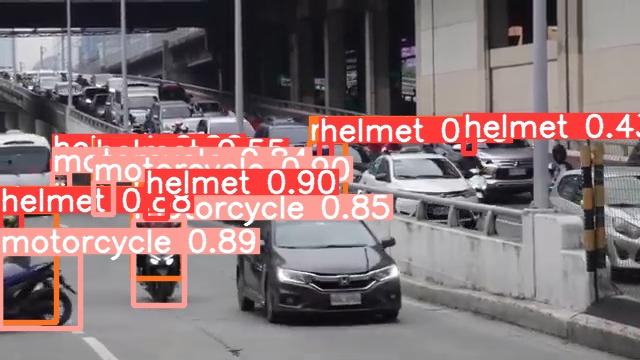

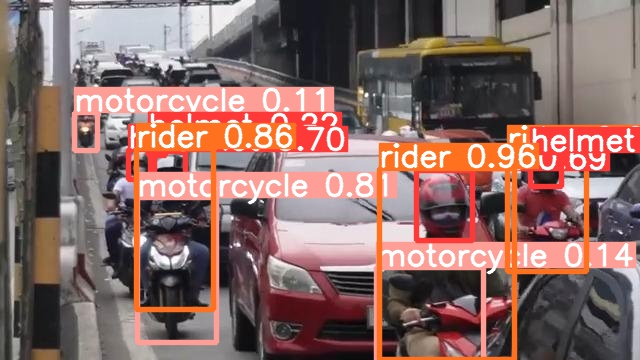

In [ ]:
import glob

from IPython.display import Image, display

for image_path in glob.glob(f'{HOME}/yolov9/runs/detect/exp/*.jpg')[:5]:
      display(Image(filename=image_path, width=600))

## Download Custom Trained Weights

In [ ]:
# optional, zip to download weights and results locally

!zip -r export.zip runs/detect
!zip -r export.zip runs/train/exp3/weights/best.pt
!zip export.zip runs/train/exp/*

  adding: runs/detect/ (stored 0%)
  adding: runs/detect/exp/ (stored 0%)
  adding: runs/detect/exp/yt-viRzDYxNHA-0081_jpg.rf.ecaba1f4f02749a224776ea4645eef82.jpg (deflated 4%)
  adding: runs/detect/exp/yt-viRzDYxNHA-0134_jpg.rf.2cb378e9de898910d367b383da3731f8.jpg (deflated 3%)
  adding: runs/detect/exp/yt-viRzDYxNHA-0146_jpg.rf.e4ffe116e0789d7b3dd7499f426e622a.jpg (deflated 2%)
  adding: runs/detect/exp/yt-viRzDYxNHA-0021_jpg.rf.4961dde75e6468d24bcc18ccad678076.jpg (deflated 2%)
  adding: runs/detect/exp/yt-viRzDYxNHA-0075_jpg.rf.f41db259b56d694966ae358d2ddc9b2e.jpg (deflated 2%)
  adding: runs/detect/exp/yt-viRzDYxNHA-0157_jpg.rf.b6c6b67455e3a562f838031196d03332.jpg (deflated 3%)
  adding: runs/detect/exp/yt-viRzDYxNHA-0190_jpg.rf.2bbbee6f8abbf7ceeb9fb2b93aaefd1c.jpg (deflated 3%)
  adding: runs/detect/exp/yt-viRzDYxNHA-0114_jpg.rf.f6e0c46337819aff86cafd1bc3f8cdf3.jpg (deflated 3%)
  adding: runs/detect/exp/yt-viRzDYxNHA-0080_jpg.rf.67e1e8f03a67c3250f5f80173c2f4bef.jpg (deflated 5%)

In [ ]:
from google.colab import files
files.download("/content/yolov9/export.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Deep Sort

Download Trained YOLOV9 Weight

In [ ]:
! gdown [redacted]

In [ ]:
%cd {HOME}/YOLOv9_DeepSORT

[Errno 2] No such file or directory: '{HOME}/YOLOv9_DeepSORT'
/content/YOLOv9_DeepSORT/yolov9


In [ ]:
!pwd

/content/YOLOv9_DeepSORT/yolov9


In [ ]:
! gdown --id [redacted]

In [ ]:
# compress downloaded video
!ffmpeg -hide_banner -loglevel error -i /content/YOLOv9_DeepSORT/yolov9/good_weather.mp4 -vcodec libx264 /content/YOLOv9_DeepSORT/data/ped_track.mp4 -y

# specify to 60 seconds
!ffmpeg -hide_banner -loglevel error -y -i /content/YOLOv9_DeepSORT/yolov9/good_weather.mp4 -t 60 /content/YOLOv9_DeepSORT/data/ped_track.mp4

## Play Input Video

In [ ]:
from IPython.display import HTML
from base64 import b64encode

def play_video(filename):
  html = ''
  video = open(filename,'rb').read()
  src = 'data:video/mp4;base64,' + b64encode(video).decode()
  html += fr'<video width=900 controls autoplay loop><source src="%s" type="video/mp4"></video>' % src
  return HTML(html)

In [ ]:
SOURCE_VIDEO_PATH = "/content/YOLOv9_DeepSORT/data/ped_track.mp4"
OUTPUT_VIDEO_PATH = "/content/output.mp4"
BLUR_ID = None
CONF = 0.6
CLASS_ID = None

In [ ]:
import cv2
import torch
import time
import colorsys
import numpy as np
from absl import app, flags
from absl.flags import FLAGS
from deep_sort_realtime.deepsort_tracker import DeepSort
from models.common import DetectMultiBackend, AutoShape

In [ ]:
def draw_corner_rect(img, bbox, line_length=30, line_thickness=5, rect_thickness=1,
                     rect_color=(255, 0, 255), line_color=(0, 255, 0)):
    x, y, w, h = bbox
    x1, y1 = x + w, y + h

    if rect_thickness != 0:
        cv2.rectangle(img, bbox, rect_color, rect_thickness)

    # Top Left  x, y
    cv2.line(img, (x, y), (x + line_length, y), line_color, line_thickness)
    cv2.line(img, (x, y), (x, y + line_length), line_color, line_thickness)

    # Top Right  x1, y
    cv2.line(img, (x1, y), (x1 - line_length, y), line_color, line_thickness)
    cv2.line(img, (x1, y), (x1, y + line_length), line_color, line_thickness)

    # Bottom Left  x, y1
    cv2.line(img, (x, y1), (x + line_length, y1), line_color, line_thickness)
    cv2.line(img, (x, y1), (x, y1 - line_length), line_color, line_thickness)

    # Bottom Right  x1, y1
    cv2.line(img, (x1, y1), (x1 - line_length, y1), line_color, line_thickness)
    cv2.line(img, (x1, y1), (x1, y1 - line_length), line_color, line_thickness)

    return img

Note: Change the class names in
/content/YOLOv9_DeepSORT/configs/coco.names
to helmet, motorcycle and rider

In [ ]:
cap = cv2.VideoCapture(SOURCE_VIDEO_PATH)

frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = int(cap.get(cv2.CAP_PROP_FPS))
# video writer objects
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
writer = cv2.VideoWriter(OUTPUT_VIDEO_PATH, fourcc, fps, (frame_width, frame_height))

# Initialize the DeepSort tracker
tracker = DeepSort(max_age=50)
# select device (CPU or GPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using:{device}")
# Load YOLO model
model = DetectMultiBackend(weights='/content/Hype1goodWeatherBest.pt',device=device, fuse=True) #Change weight path on custom trained weights
model = AutoShape(model)

# Load the Custom class labels
classes_path = "/content/YOLOv9_DeepSORT/configs/coco.names"
with open(classes_path, "r") as f:
  class_names = f.read().strip().split("\n")

# Create a list of random colors to represent each class
np.random.seed(42)
colors = np.random.randint(0, 255, size=(len(class_names), 3))

# FPS calculation variables
frame_count = 0
start_time = time.time()

while True:
  ret, frame = cap.read()
  if not ret:
      break
  # Run model on each frame
  results = model(frame)
  detect = []
  for det in results.pred[0]:
    label, confidence, bbox = det[5], det[4], det[:4]
    x1, y1, x2, y2 = map(int, bbox)
    class_id = int(label)

    # Filter out weak detections by confidence threshold and class_id
    if CLASS_ID is None:
        if confidence < CONF:
            continue
    else:
        if class_id != CLASS_ID or confidence < CONF:
            continue

    detect.append([[x1, y1, x2 - x1, y2 - y1], confidence, class_id])

  tracks = tracker.update_tracks(detect, frame=frame)

  for track in tracks:
    if not track.is_confirmed():
      continue
    track_id = track.track_id
    ltrb = track.to_ltrb()
    class_id = track.get_det_class()
    x1, y1, x2, y2 = map(int, ltrb)
    color = colors[class_id]
    B, G, R = map(int, color)
    text = f"{track_id} - {class_names[class_id]}"

    frame = draw_corner_rect(frame, (x1, y1, x2 - x1, y2 - y1), line_length=15, line_thickness=3, rect_thickness=1, rect_color=(B, G, R), line_color=(R, G, B))
    cv2.rectangle(frame, (x1, y1), (x2, y2), (B, G, R), 2)
    cv2.rectangle(frame, (x1 - 1, y1 - 20), (x1 + len(text) * 10, y1), (B, G, R), -1)
    cv2.putText(frame, text, (x1 + 5, y1 - 7), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 2)

    # Apply Gaussian Blur
    if BLUR_ID is not None and class_id == BLUR_ID:
      if 0 <= x1 < x2 <= frame.shape[1] and 0 <= y1 < y2 <= frame.shape[0]:
        frame[y1:y2, x1:x2] = cv2.GaussianBlur(frame[y1:y2, x1:x2], (99, 99), 3)

  writer.write(frame)

  frame_count += 1
  if frame_count % 10 == 0:
    elapsed_time = time.time() - start_time
    fps_calc = frame_count / elapsed_time
    print(f"FPS: {fps_calc:.2f}")

  if cv2.waitKey(1) & 0xFF == ord('q'):
      break

cap.release()
writer.release()

Using:cpu


Fusing layers... 
yolov9-e summary: 1119 layers, 69351410 parameters, 0 gradients, 243.3 GFLOPs
Adding AutoShape... 


FPS: 0.21
FPS: 0.22
FPS: 0.21
FPS: 0.21
FPS: 0.21
FPS: 0.21
FPS: 0.21
FPS: 0.21
FPS: 0.21
FPS: 0.21
FPS: 0.21
FPS: 0.21
FPS: 0.21
FPS: 0.21
FPS: 0.21
FPS: 0.21
FPS: 0.21
FPS: 0.21
FPS: 0.21
FPS: 0.21
FPS: 0.21
FPS: 0.21
FPS: 0.21
FPS: 0.21
FPS: 0.21
FPS: 0.21
FPS: 0.21
FPS: 0.21
FPS: 0.21
FPS: 0.21
FPS: 0.21
FPS: 0.21
FPS: 0.21
FPS: 0.22
FPS: 0.22
FPS: 0.22
FPS: 0.22
FPS: 0.22
FPS: 0.22
FPS: 0.22
FPS: 0.22
FPS: 0.22
FPS: 0.22
FPS: 0.22
FPS: 0.22
FPS: 0.22
FPS: 0.22
FPS: 0.22
FPS: 0.22
FPS: 0.22
FPS: 0.22
FPS: 0.22
FPS: 0.22
FPS: 0.22
FPS: 0.23
FPS: 0.23
FPS: 0.23
FPS: 0.23
FPS: 0.23
FPS: 0.23
FPS: 0.23
FPS: 0.23
FPS: 0.23
FPS: 0.23
FPS: 0.23
FPS: 0.23
FPS: 0.23
FPS: 0.23
FPS: 0.23
FPS: 0.23
FPS: 0.23
FPS: 0.23
FPS: 0.23
FPS: 0.23
FPS: 0.23
FPS: 0.23
FPS: 0.23
FPS: 0.23
FPS: 0.23
FPS: 0.23
FPS: 0.23
FPS: 0.23
FPS: 0.23
FPS: 0.23
FPS: 0.23
FPS: 0.23
FPS: 0.23
FPS: 0.23
FPS: 0.23
FPS: 0.23
FPS: 0.23
FPS: 0.23
FPS: 0.23
FPS: 0.23
FPS: 0.23
FPS: 0.23
FPS: 0.23
FPS: 0.23
FPS: 0.23
FPS: 0.23


## DeepSort Object Tracking

## Play Output Video

In [ ]:
!ffmpeg -hide_banner -loglevel error -i /content/output.mp4 -vcodec libx264 /content/ped_track.mp4 -y
play_video("/content/ped_track.mp4")